# Fase 5 — Evaluación comparativa unificada
**Proyecto:** FruitVision — Clasificación de Calidad de Frutas

---
Compara en igualdad de condiciones (mismo test, split **sin fuga**) los modelos
ya entrenados: **Baseline, Random Forest, XGBoost, CNN**. Incluye tabla,
matrices de confusión, **análisis de errores** y un **desglose por fuente**
(Kaggle vs propio) que mide la generalización al dataset recolectado por el grupo.

Este notebook **NO entrena**: carga los modelos guardados y los evalúa.

In [1]:
import sys, pathlib, os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '2'
ROOT = pathlib.Path.cwd()
while not (ROOT / "src").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))
import numpy as np, pandas as pd, joblib, cv2, collections
import matplotlib.pyplot as plt, seaborn as sns
sns.set_theme(style="whitegrid")
import tensorflow as tf
from sklearn.dummy import DummyClassifier
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)
from src.config import QUALITY_CLASSES, CNN_IMG_SIZE, MODELS_DIR, FIGURES_DIR
from src.data.preprocessing import load_manifest
from src.features.extract import build_feature_matrix
from src.data.paths import load_image_rgb

I0000 00:00:1780821857.765553 1161446 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


I0000 00:00:1780821859.500497 1161446 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. Cargar modelos y datos de prueba

In [2]:
Xtr, ytr = build_feature_matrix(load_manifest('train'), 'train')
te = load_manifest('test')
Xte, yte = build_feature_matrix(te, 'test')
def load_imgs(manifest, size=CNN_IMG_SIZE):
    X = np.zeros((len(manifest), *size, 3), np.float32)
    for i, p in enumerate(manifest['abs_path']):
        img = load_image_rgb(p)
        if img is not None: X[i] = cv2.resize(img, size).astype(np.float32) / 255.0
    return X
Xte_img = load_imgs(te)
rf = joblib.load(MODELS_DIR/"random_forest.pkl"); xgbm = joblib.load(MODELS_DIR/"xgboost.pkl")
cnn = tf.keras.models.load_model(MODELS_DIR/"cnn_quality.keras")
dummy = DummyClassifier(strategy='most_frequent').fit(Xtr, ytr)
print("Test:", len(te), "| por fuente:", te['source'].value_counts().to_dict())

E0000 00:00:1780821865.615748 1161446 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.


Test: 1076 | por fuente: {'kaggle': 692, 'propio': 384}


## 2. Predicciones

In [3]:
preds = {'Baseline': dummy.predict(Xte), 'Random Forest': rf.predict(Xte),
         'XGBoost': xgbm.predict(Xte), 'CNN': cnn.predict(Xte_img, verbose=0).argmax(1)}

## 3. Tabla comparativa

               accuracy  f1_macro
modelo                           
Baseline          0.328     0.165
Random Forest     0.886     0.886
XGBoost           0.905     0.905
CNN               0.886     0.886


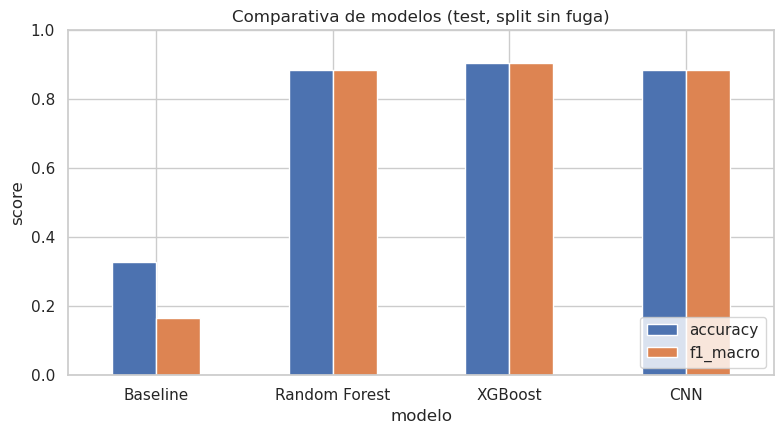

In [4]:
results = pd.DataFrame([{'modelo':n, 'accuracy':accuracy_score(yte,p),
    'f1_macro':f1_score(yte,p,average='macro')} for n,p in preds.items()]).set_index('modelo')
print(results.round(3))
ax = results.plot.bar(figsize=(8,4.5), rot=0); ax.set_ylim(0,1); ax.legend(loc='lower right')
ax.set_title("Comparativa de modelos (test, split sin fuga)"); ax.set_ylabel("score")
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase5_comparativa.pdf", bbox_inches="tight"); plt.show()

## 4. Métricas por clase y matrices de confusión

In [5]:
for name in ['Random Forest','XGBoost','CNN']:
    print(f"=== {name} ==="); print(classification_report(yte, preds[name], target_names=QUALITY_CLASSES, digits=3))

=== Random Forest ===
              precision    recall  f1-score   support

     Premium      0.870     0.863     0.867       365
    Estándar      0.860     0.891     0.875       358
    Descarte      0.930     0.904     0.917       353

    accuracy                          0.886      1076
   macro avg      0.887     0.886     0.886      1076
weighted avg      0.886     0.886     0.886      1076

=== XGBoost ===
              precision    recall  f1-score   support

     Premium      0.903     0.866     0.884       365
    Estándar      0.886     0.916     0.901       358
    Descarte      0.927     0.935     0.931       353

    accuracy                          0.905      1076
   macro avg      0.905     0.906     0.905      1076
weighted avg      0.905     0.905     0.905      1076

=== CNN ===
              precision    recall  f1-score   support

     Premium      0.825     0.929     0.874       365
    Estándar      0.929     0.804     0.862       358
    Descarte      0.918  

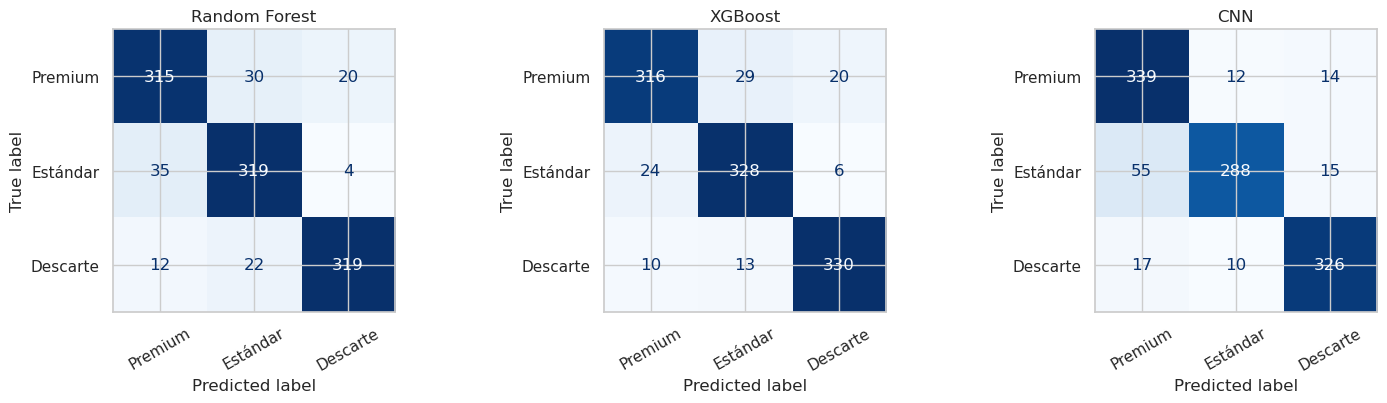

In [6]:
fig, ax = plt.subplots(1, 3, figsize=(15, 4.2))
for a, name in zip(ax, ['Random Forest','XGBoost','CNN']):
    ConfusionMatrixDisplay(confusion_matrix(yte, preds[name]), display_labels=QUALITY_CLASSES).plot(ax=a, cmap='Blues', colorbar=False)
    a.set_title(name); a.tick_params(axis='x', rotation=30)
plt.tight_layout(); plt.savefig(FIGURES_DIR/"fase5_confusion.pdf", bbox_inches="tight"); plt.show()

## 5. Análisis de errores (mejor modelo)

Mejor modelo: XGBoost | errores: 102/1076

Confusiones (real -> predicho):
  Premium   -> Estándar : 29
  Estándar  -> Premium  : 24
  Premium   -> Descarte : 20
  Descarte  -> Estándar : 13
  Descarte  -> Premium  : 10


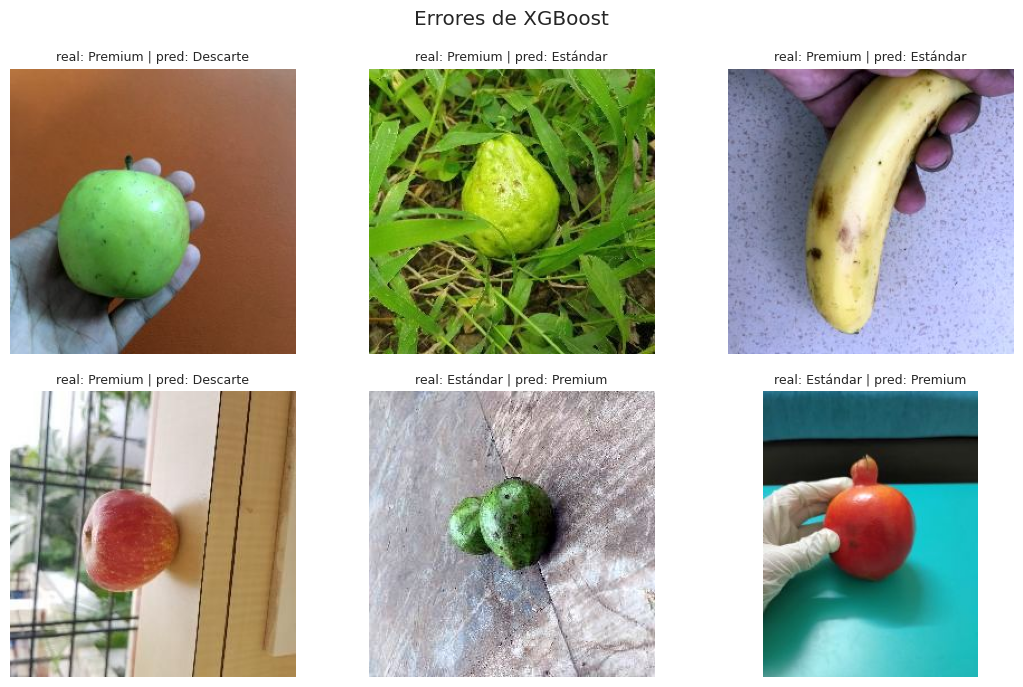

In [7]:
best_name = results.drop('Baseline')['f1_macro'].idxmax(); best = preds[best_name]
wrong = np.where(best != yte)[0]
print(f"Mejor modelo: {best_name} | errores: {len(wrong)}/{len(yte)}")
pairs = collections.Counter((QUALITY_CLASSES[yte[i]], QUALITY_CLASSES[best[i]]) for i in wrong)
print("\nConfusiones (real -> predicho):")
for (a,b),c in pairs.most_common(5): print(f"  {a:9s} -> {b:9s}: {c}")
sample = wrong[:6]
fig, axes = plt.subplots(2, 3, figsize=(11, 7))
for ax, i in zip(axes.flatten(), sample):
    ax.imshow(load_image_rgb(te.iloc[i]['abs_path'])); ax.axis('off')
    ax.set_title(f"real: {QUALITY_CLASSES[yte[i]]} | pred: {QUALITY_CLASSES[best[i]]}", fontsize=9)
for ax in axes.flatten()[len(sample):]: ax.axis('off')
plt.suptitle(f"Errores de {best_name}"); plt.tight_layout()
plt.savefig(FIGURES_DIR/"fase5_errores.pdf", bbox_inches="tight"); plt.show()

## 6. Desglose por fuente: Kaggle vs Dataset propio
Medimos el desempeño por separado en imágenes de Kaggle y en las recolectadas por
el grupo. Una caída en el dataset propio indica *domain shift* (otra cámara/luz/
fondo) — la prueba de generalización real. La clase **Estándar** solo aparece en
las imágenes propias (es la fuente de esa clase).

In [8]:
rows = []
for src in ['kaggle','propio']:
    mask = (te['source']==src).values
    if mask.sum()==0: continue
    for name,p in preds.items():
        if name=='Baseline': continue
        rows.append({'fuente':src, 'modelo':name, 'n':int(mask.sum()),
                     'accuracy':accuracy_score(yte[mask], p[mask]),
                     'f1_macro':f1_score(yte[mask], p[mask], average='macro')})
by_source = pd.DataFrame(rows).set_index(['fuente','modelo'])
print(by_source.round(3))

                        n  accuracy  f1_macro
fuente modelo                                
kaggle Random Forest  692     0.861     0.760
       XGBoost        692     0.880     0.806
       CNN            692     0.871     0.713
propio Random Forest  384     0.930     0.813
       XGBoost        384     0.951     0.886
       CNN            384     0.911     0.808


## 7. Sobre la salida de **tamaño** (aclaración importante)
El tamaño NO lo predice un modelo: se mide por segmentación como
**diámetro equivalente / diagonal de la imagen**. Es decir, refleja **cuánto llena
la fruta el encuadre**, no su diámetro físico real (que requeriría una referencia
de escala en la foto). Por eso aparece correlacionado con la fuente/tipo de foto.

In [9]:
import pandas as pd
ct = pd.crosstab(te['quality'], te['size']).reindex(index=QUALITY_CLASSES,
        columns=['Pequeño','Mediano','Grande'])
print("Tamaño (estimado) × calidad en test:"); print(ct.to_string())
print("\n→ El tamaño es 'fracción del encuadre ocupada por la fruta', medida")
print("  reproducible y útil para la app, pero NO equivale a tamaño físico.")

Tamaño (estimado) × calidad en test:
size      Pequeño  Mediano  Grande
quality                           
Premium        52      123     190
Estándar      129      102     127
Descarte      145      138      70

→ El tamaño es 'fracción del encuadre ocupada por la fruta', medida
  reproducible y útil para la app, pero NO equivale a tamaño físico.


## 8. Ablation (resumen): ¿ayudó el enriquecimiento Mixed?

In [10]:
import pandas as pd
from src.config import MODELS_DIR
for name,f in [('ML (RF/XGB)','ablation_ml.csv'),('CNN','ablation_cnn.csv')]:
    p=MODELS_DIR/f
    if p.exists():
        print(f"=== {name} ===)"); print(pd.read_csv(p).round(4).to_string(index=False)); print()
print("Los modelos guardados corresponden a la variante ganadora por modelo.")

=== ML (RF/XGB) ===)
       modelo      variante  accuracy  f1_macro
Random Forest con mixed_seg    0.8485    0.8483
      XGBoost con mixed_seg    0.8913    0.8909
Random Forest sin mixed_seg    0.8857    0.8861
      XGBoost sin mixed_seg    0.9052    0.9053

=== CNN ===)
     variante  accuracy  f1_macro
con mixed_seg    0.8857    0.8856
sin mixed_seg    0.7528    0.7551

Los modelos guardados corresponden a la variante ganadora por modelo.


## 9. Resumen de la Fase 5
- Comparación justa (mismo test, split **sin fuga**), 3 clases balanceadas en test.
- Tabla, matrices de confusión y **análisis de errores**.
- **Desglose por fuente** (Kaggle vs propio) evidencia de generalización.
- **Ablation** con/sin enriquecimiento Mixed: se conserva la variante ganadora.
- **Tamaño**: medición por segmentación (fracción del encuadre), no físico.